# Getting started with GPE simulation

This notebook contains examples on how to use the GPE library in HeliumTools to perform simulations of the Gross-Pitaeveski equation. More information and documentation can be found in:

https://github.com/qo-eth/TorchGPE/blob/main/README.md

https://qo-eth.github.io/TorchGPE/

# BEC in a 1D harmonic trap
In this example, we solve the GP equation for a 2D-harmonic trap. We first find the ground state and after we evolve the BEC order parameter after switch off of the trap.

## Import libraries

In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import torch
import numpy as np
import scipy.constants as spconsts

from heliumtools.simulation.GPE.bec1D import Gas
import heliumtools.simulation.GPE.bec1D.callbacks as call
import heliumtools.simulation.GPE.bec1D.potentials as potentials
from heliumtools.simulation.GPE.utils.potentials import s_ramp , quench

/home/rui/HeliumTools/hellenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Finding Ground state BEC
We start by defining the trap frequency and the lattice. These set the caractering time and length adimensionalization.

In [2]:
# define He mass in SI units
mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

# get hbar in SI units
hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

# define trap frequency in s^-1 equal for both axis
omegaTrap = 2*np.pi*100

# compute characteristic length. We use the ground state of the quantum harmonic oscillator as reference
length_Trap = np.sqrt(hbar/(omegaTrap*mHe))

# define lattice velocity
vLatt = 50e-3 # m/s
# compute lattice wavector 
kLatt = mHe*vLatt/hbar
# lattice characteristic length
length_Lattice = 1/kLatt
# compute recoil energy
ELatt = 0.5*mHe*np.power(vLatt,2)
# compute recoil frequency
omegaLatt = ELatt/hbar
# lattice depth
depthLatt = -2*np.pi*5e3 # in s^-1

print("k_{Latt} = "+str(kLatt))
print("omega_{Latt} = "+str(omegaLatt))
print("omega_{Latt}/omegaTrap = "+str(omegaLatt/omegaTrap))
print("length_Lattice/length_Trap = "+str(length_Lattice/length_Trap))

k_{Latt} = 3149219.55796656
omega_{Latt} = 78730.48894916402
omega_{Latt}/omegaTrap = 125.30346488301294
length_Lattice/length_Trap = 0.06316892148776533


In [3]:
# We instanciate the Gas class. We define the element we want to consider. This element must be defined in utils/elements.py
# we set the number of atoms in the BEC
# we set the grid_size step in m
grid_size = 50*length_Trap
# we define the number of points of the grid.
step = length_Lattice/10
Npoints = int(grid_size/(step))
print("Grid with "+str(Npoints))
# we set the float type to 32 bit to save memory space
# we set the complex type to 64 bit to save memory space
# calculation is performed on cpu
# define BEC adim length so that it is consistent with the problem


# instanciate Gas class
bec = Gas(element = "He*" , N_particles = 5e4, grid_size = grid_size, N_grid = Npoints ,  
        device = "cpu" , float_dtype = torch.float , complex_dtype = torch.complex64 , adimensionalization_length = length_Lattice)

Grid with 7915


Now we define the ground state wavefunction of the harmonic oscillator for latter use

In [4]:
# 1D-harmonic ocscillator ground state
# X and Y should be in adim units
# this function is to be used to compare numerical result
# omega is the trap frequency and gas is the instance of the Gas() class
# dimension is either 1 or 2 depending you want the 1D or 2D dimension. 
# if you choose 1D, by default the wavefunction is computed along X
def HarmonicGroundState(X,omega,gas):
    # define He mass in SI units
    mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

    # get hbar in SI units
    hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

    # get adim length
    lAdim = gas.adim_length

    # compute wavefunction length parameter
    length = np.sqrt(hbar/(omega*mHe))

    # compute norm factor
    norm = 1/np.sqrt(np.pi*np.power(length,2))

    arg = X*lAdim/length
    phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)
    return phi*np.sqrt(lAdim)

We now define the harmonic trap potential

In [5]:
# instanciate trap potential
trap = potentials.Trap(omegax = omegaTrap)

We now define the nonlinar interaction term of the GP equation as a nonlinear contact potential

In [6]:
""" compute Bohr radius """
# electron mass
me = spconsts.physical_constants["electron mass"][0]
# light velocity
light = spconsts.physical_constants["speed of light in vacuum"][0]
# fine structure constant
fineStructure = spconsts.physical_constants["fine-structure constant"][0]
# compute Bohr radius
Bohr = hbar/(me*light*fineStructure)

""" define scattering length for He* in units of Bohr radius """
# scattering length in SI units
aScatter = 7.512*1e-9 # m
# set in Bohr radius units
aScatter = aScatter/Bohr

""" define renormalization parameter for the scattering length to account for the missing third dimension """
# according to the Bragg spetroscopy, we expect that longitudinal density parameter is
n1 = 1.3/(aScatter*Bohr)
# define renormalization parameter
a_orth = bec.N_particles/(np.sqrt(2*np.pi)*n1)

""" define contact potential """
contact = potentials.Contact(a_s = aScatter , a_orth = a_orth)

Define intial wavefunction

In [27]:
# we define the initial wavefunction to be the ground state of the harmonic oscillator
bec.psi = HarmonicGroundState(bec.X,omegaTrap,bec)

/tmp/ipykernel_460103/3195792783.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)


Find ground state of GP equation

In [28]:
# define function that measures convergence of calculation
CP = 500
convergence = call.L2Norm(compute_every = CP, print_every = 1e4)

# find the ground state
Nit = 5e3
time_step = -1j/(10*omegaTrap)
bec.ground_state(potentials=[trap], N_iterations=Nit,callbacks=[convergence],time_step=time_step)

Ground state:   0%|          | 9/5000 [00:00<01:00]

Ground state:   0%|          | 19/5000 [00:00<00:55]

tensor(8.6482e-05)


Ground state: 100%|██████████| 5000/5000 [01:02<00:00]


/tmp/ipykernel_460103/3195792783.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)


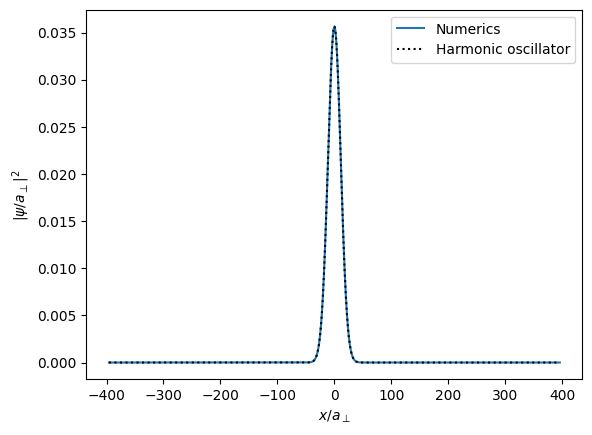

In [29]:
fig, ax = plt.subplots()


ax.plot(bec.x,bec.density,label = "Numerics")

""" 1D plot along diagonal """

# plot original guess which is the quantum harmonic oscillator
phiHarmonic = HarmonicGroundState(bec.X,omegaTrap,bec)
ax.plot(bec.x,phiHarmonic**2,label = "Harmonic oscillator",color = "black" , ls = "dotted")

ax.set_xlabel(r"$x/a_{\bot}$")
ax.set_ylabel(r"$y/a_{\bot}$")
ax.set_xlabel(r"$x/a_{\bot}$")
ax.set_ylabel(r"$|\psi/a_{\bot}|^2$")
ax.legend()

plt.show()

Plot convergence of calculation

Text(0.5, 1.0, 'Convergence of calculation')

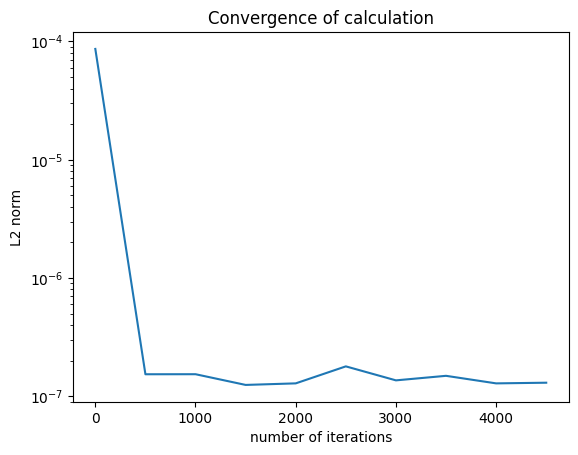

In [30]:
plt.plot(np.arange(1,Nit+1,CP),convergence.norms)
plt.xlabel("number of iterations")
plt.ylabel("L2 norm")
plt.yscale("log")
plt.title("Convergence of calculation")

## In situ Bragg

Define the square pulse

In [7]:
def SquarePulse(depth,t0,t1):
    """Implements a Square pulse
    Args:
        v0 (float): Depth of lattice potential
        t0 (float): The beggining of the pulse
        tf (float): The end of the pulse

    Returns:
        float: The value of the pulse at time :math:`t`
        """
    return lambda t: depth if (t >= t0)*(t <= t1)  else 0.0

def PulsePhase(detuning):
    """ implements the phase of the square pulse 
    Args:
        detuning (float): detuning of Bragg pulse """
    return lambda t: 2*np.pi*detuning*t


Define Bragg pulse

In [13]:
# define pulse duration
duration = 5/2 * np.pi/np.abs(depthLatt)
# beggining of pulse
t0 = 100e-6

# initialize pulse functions
pulse = SquarePulse(depthLatt/omegaLatt,t0,t0 + duration)
phase = PulsePhase(detuning = omegaLatt/(2*np.pi))

# instanciate lattice potential
lattice = potentials.Lattice(kLatt = kLatt , V0 =  pulse , phi = phase)

Solve differential equation

In [14]:
# define calculation step
step = 1/(50*omegaLatt)
# define end of computation
tFinal = t0 + duration + 10000e-6
# compute number of iterations
Nit = round(tFinal/step)

print("Number of iterations is "+str(Nit))


Number of iterations is 40743


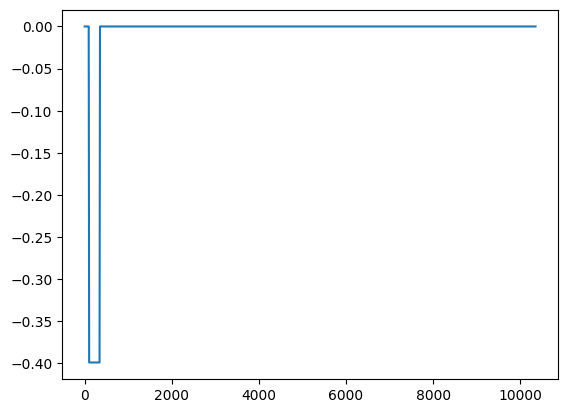

In [15]:
t = np.linspace(0.0,tFinal,1000)
temp = [pulse(ti) for ti in t]
plt.plot(t*1e6,temp)
plt.show()

In [16]:
bec.psi = HarmonicGroundState(bec.X,omegaTrap,bec)

/tmp/ipykernel_14491/3195792783.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)


In [17]:
# define callback to retrieve the density of the wavefunction at each iteration number multiple of CP
CP = 200
density = call.BecEvolution(compute_every = CP, print_every = 1e4)

# define psi array to save intermidiate calculations
bec.propagate(tFinal, step, [trap, lattice] , [density])

Propagation:   0%|          | 0/40743 [00:00<?]

Propagation: 100%|██████████| 40743/40743 [06:28<00:00]


Plot evolution

/tmp/ipykernel_14491/3195792783.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)


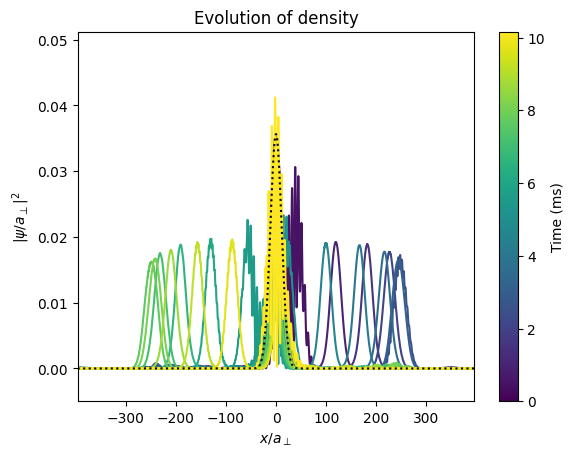

In [18]:
fig, ax = plt.subplots()

# get x
x = bec.X.detach().numpy()

# Make a sequence of x,y pairs
segment = []
ymax = []
time = []
for i in range(0,len(density.norms),10):
    y = np.copy(density.norms[i].detach().numpy())
    segment.append(np.column_stack([x, y]))
    ymax.append(np.amax(y))
    time.append(i*CP*step*1e3)

# set lims
ax.set_xlim(np.amin(x),np.amax(x))
ax.set_ylim(-0.005,np.amax(ymax) + 0.01)

line_segments = LineCollection(segment , linestyles='solid')


line_segments.set_array(time)
ax.add_collection(line_segments)
axcb = fig.colorbar(line_segments)
axcb.set_label('Time (ms)')
ax.set_title('Evolution of density')
ax.set_xlabel(r"$x/a_{\bot}$")
ax.set_ylabel(r"$|\psi/a_{\bot}|^2$")

# plot original wavefunction
phiHarmonic = HarmonicGroundState(bec.X,omegaTrap,bec)
ax.plot(bec.x,phiHarmonic**2,label = "Harmonic oscillator",color = "black" , ls = "dotted")

plt.sci(line_segments)  # This allows interactive changing of the colormap.
plt.show()

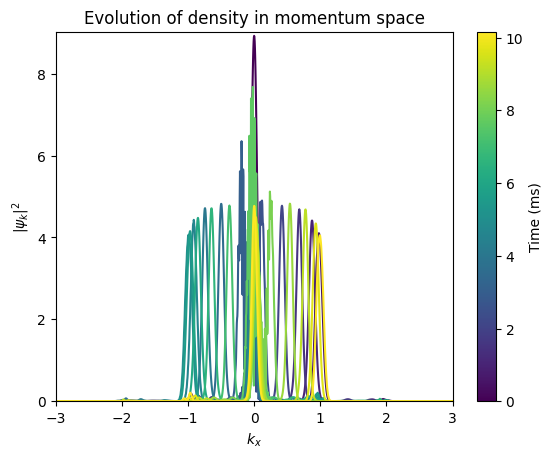

In [22]:
fig, ax = plt.subplots()

# get x
kx = bec.Kx.detach().numpy()

# Make a sequence of x,y pairs
segment = []
ymax = []
time = []
for i in range(0,len(density.normsk),10):
    y = np.copy(density.normsk[i].detach().numpy())
    segment.append(np.column_stack([kx, y]))
    ymax.append(np.amax(y))
    time.append(i*CP*step*1e3)

# set lims
ax.set_xlim(-3,3)
ax.set_ylim(-0.005,np.amax(ymax) + 0.1)

line_segments = LineCollection(segment , linestyles='solid')


line_segments.set_array(time)
ax.add_collection(line_segments)
axcb = fig.colorbar(line_segments)
axcb.set_label('Time (ms)')
ax.set_title('Evolution of density in momentum space')
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$|\psi_k|^2$")

# plot original wavefunction
#phiHarmonic = HarmonicGroundState(bec.X,omegaTrap,bec)
#x.plot(bec.kx,phiHarmonic**2,label = "Harmonic oscillator",color = "black" , ls = "dotted")

plt.sci(line_segments)  # This allows interactive changing of the colormap.
plt.show()

# BEC in a 2D harmonic trap

In this example, we solve the GP equation for a 2D-harmonic trap. We first find the ground state and after we evolve the BEC order parameter after switch off of the trap.

## Import libraries

In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import torch
import numpy as np
import scipy.constants as spconsts

from heliumtools.simulation.GPE.bec2D import Gas
import heliumtools.simulation.GPE.utils.callbacks as call
#import heliumtools.simulation.GPE.bec2D.callbacks as call2
import heliumtools.simulation.GPE.bec2D.potentials as potentials
from heliumtools.simulation.GPE.utils.potentials import s_ramp , quench

/home/rui/HeliumTools/hellenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Finding Ground state BEC

We start by defining the trap frequency in both x and y-axis. This trap frequency sets the caractering time and length adimensionalization.

In [2]:
# define He mass in SI units
mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

# get hbar in SI units
hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

# define trap frequency in s^-1 equal for both axis
omegaTrap = 2*np.pi*900

# compute characteristic length. We use the ground state of the quantum harmonic oscillator as reference
length_Trap = np.sqrt(hbar/(omegaTrap*mHe))


In [3]:
# We instanciate the Gas class. We define the element we want to consider. This element must be defined in utils/elements.py
# we set the number of atoms in the BEC
# we set the grid_size step in m
grid_size = 40*length_Trap
# we define the number of points of the grid for each axis. Here we set the same sunmber of points in each direction
step = length_Trap/20
Npoints = int(grid_size/(step))
print("Grid with "+str(Npoints)+" in each axis")
# we set the float type to 32 bit to save memory space
# we set the complex type to 64 bit to save memory space
# calculation is performed on cpu
# define BEC adim length so that it is consistent with the problem


# instanciate Gas class
bec = Gas(element = "He*" , N_particles = 5e4, grid_size = grid_size, N_grid = Npoints ,  
        device = "cpu" , float_dtype = torch.float , complex_dtype = torch.complex64 , adimensionalization_length = length_Trap)

Grid with 800 in each axis


Now we define the ground state wavefunction of the harmonic oscillator for latter use

In [4]:
# 2D-harmonic ocscillator ground state
# X and Y should be in adim units
# this function is to be used to compare numerical result
# omega is the trap frequency and gas is the instance of the Gas() class
# dimension is either 1 or 2 depending you want the 1D or 2D dimension. 
# if you choose 1D, by default the wavefunction is computed along X
def HarmonicGroundState(X,Y,omega,gas,dimension):
    # define He mass in SI units
    mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

    # get hbar in SI units
    hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

    # get adim length
    lAdim = gas.adim_length

    # compute wavefunction length parameter
    length = np.sqrt(hbar/(omega*mHe))

    # compute norm factor
    norm = 1/np.sqrt(np.pi*np.power(length,2))

    # if 1D
    if dimension == "1D":
        arg = X*lAdim/length
        phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)
        return phi*np.sqrt(lAdim)

    # else compute 2D
    else:
        return HarmonicGroundState(X,Y,omega,gas,"1D")*HarmonicGroundState(Y,X,omega,gas,"1D")


# wavefunction according to the gaussian ansatz
# X and Y should be in adim units
# this function is to be used to compare numerical result
# omega is the trap frequency
def GaussianAnsatz(X,Y,omegaTrap,n1):
    # define He mass in SI units
    mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

    # get hbar in SI units
    hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

    # scattering length in SI units
    aScatter = 7.512*1e-9 # m

    # compute radius
    r = X**2 + Y **2

    # compute width
    sigma = np.power(1+4*n1*aScatter,1/4)

    return 1/np.sqrt(np.pi*sigma**2)*np.exp(-r/(2*sigma**2))   

We now define the harmonic trap potential

In [5]:
# instanciate trap potential
trap = potentials.Trap(omegax = omegaTrap, omegay = omegaTrap)

We now define the nonlinar interaction term of the GP equation as a nonlinear contact potential

In [6]:
""" compute Bohr radius """
# electron mass
me = spconsts.physical_constants["electron mass"][0]
# light velocity
light = spconsts.physical_constants["speed of light in vacuum"][0]
# fine structure constant
fineStructure = spconsts.physical_constants["fine-structure constant"][0]
# compute Bohr radius
Bohr = hbar/(me*light*fineStructure)

""" define scattering length for He* in units of Bohr radius """
# scattering length in SI units
aScatter = 7.512*1e-9 # m
# set in Bohr radius units
aScatter = aScatter/Bohr

""" define renormalization parameter for the scattering length to account for the missing third dimension """
# according to the Bragg spetroscopy, we expect that longitudinal density parameter is
n1 = 1.3/(aScatter*Bohr)
# define renormalization parameter
a_orth = bec.N_particles/(np.sqrt(2*np.pi)*n1)

""" define contact potential """
contact = potentials.Contact(a_s = aScatter , a_orth = a_orth)

Define intial wavefunction

In [7]:
# we define the initial wavefunction to be the ground state of the harmonic oscillator
#bec.psi = HarmonicGroundState(bec.X,bec.Y,omegaTrap,bec,"2D")
bec.psi = GaussianAnsatz(bec.X,bec.Y,omegaTrap,n1)

/tmp/ipykernel_866600/1014293015.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1/np.sqrt(np.pi*sigma**2)*np.exp(-r/(2*sigma**2))


Find ground state of GP equation

In [8]:
# define function that measures convergence of calculation
CP = 500
convergence = call.L2Norm(compute_every = CP, print_every = 1e4)

# find the ground state
Nit = 1.5e3
bec.ground_state(potentials=[trap,contact], N_iterations=Nit,callbacks=[convergence])

Ground state:   0%|          | 1/1500 [00:01<42:10]

tensor(0.0034)


Ground state: 100%|██████████| 1500/1500 [16:00<00:00]


Plot 2D function and cross section

/tmp/ipykernel_12723/1014293015.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)
/tmp/ipykernel_12723/1014293015.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1/np.sqrt(np.pi*sigma**2)*np.exp(-r/(2*sigma**2))


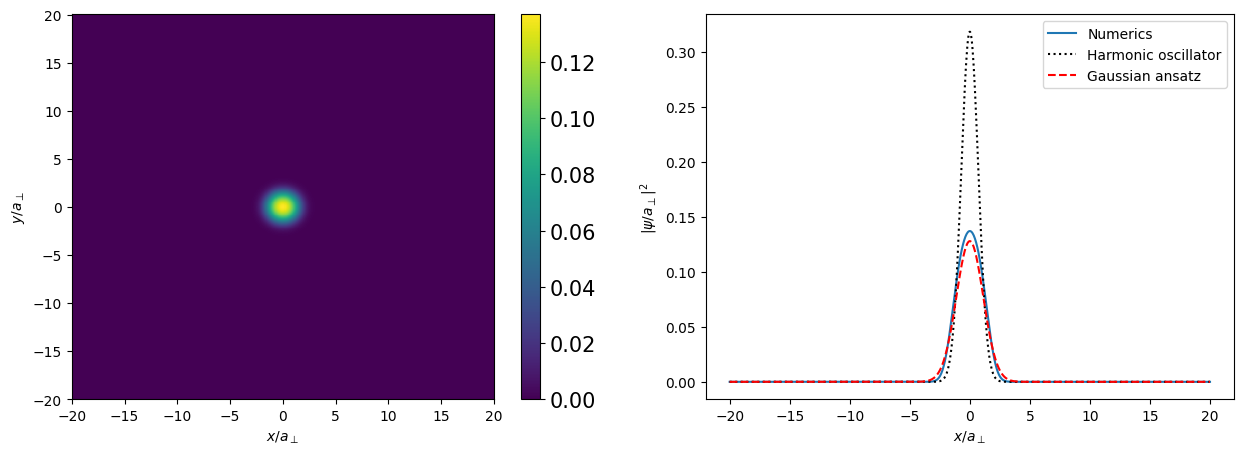

In [9]:
fig, ax = plt.subplots(nrows= 1 , ncols=2,figsize = (15,5))


""" 2D plot """
im = ax[0].pcolormesh(bec.X,bec.Y, bec.density)
cbar = fig.colorbar(im, ax = ax[0])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)

ax[1].plot(bec.X[0],bec.density[int(len(bec.density)/2)],label = "Numerics")

""" 1D plot along diagonal """

# plot original guess which is the quantum harmonic oscillator
phiHarmonic = HarmonicGroundState(bec.X,bec.Y,omegaTrap,bec,"2D")
ax[1].plot(bec.X[0],phiHarmonic[int(len(phiHarmonic)/2)]**2,label = "Harmonic oscillator",color = "black" , ls = "dotted")

# plot gaussian ansatz
ansatz = GaussianAnsatz(bec.X,bec.Y,omegaTrap,n1)
ax[1].plot(bec.X[0],ansatz[int(len(ansatz)/2)]**2,label = "Gaussian ansatz",color = "red" , ls = "dashed")


ax[0].set_xlabel(r"$x/a_{\bot}$")
ax[0].set_ylabel(r"$y/a_{\bot}$")
ax[1].set_xlabel(r"$x/a_{\bot}$")
ax[1].set_ylabel(r"$|\psi/a_{\bot}|^2$")
ax[1].legend()

plt.show()

Plot convergence of calculation

Text(0.5, 1.0, 'Convergence of calculation')

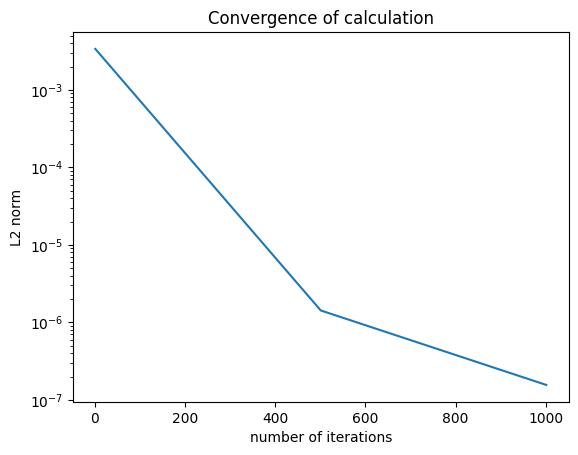

In [10]:
plt.plot(np.arange(1,Nit+1,CP),convergence.norms)
plt.xlabel("number of iterations")
plt.ylabel("L2 norm")
plt.yscale("log")
plt.title("Convergence of calculation")

## Quench the BEC

We now study the case when we open the trap

In [11]:
# define time dependent quench
# initial value if the Trap frequency and final value is zero
# we do a quench at 500 us
depth = quench(v0 = omegaTrap, v1 = 0.0, quench_time = 100e-6)

# create trap potential where trap frequencies are the quench function
trap = potentials.Trap(omegax = depth, omegay = depth)

In [12]:
# beggining of simulation is 
# define end of calculation array
tFinal = 1.5e-3
# define calculation step
step = 5e-6
# compute number of iterations
Nit = round(tFinal/step)

print("Number of iterations is "+str(Nit))


Number of iterations is 300


In [13]:
# define callback to retrieve the density of the wavefunction at each iteration number multiple of CP
CP = 10
density = call.BecEvolution(compute_every = CP, print_every = 1e4)

# define psi array to save intermidiate calculations
bec.propagate(tFinal, step, [trap, contact] , [density])

Propagation: 100%|██████████| 300/300 [03:54<00:00]


Plot evolution

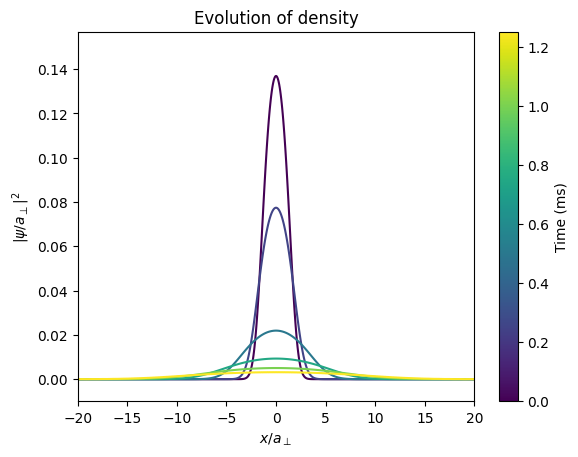

In [14]:
fig, ax = plt.subplots()

# get x
x = bec.X[0].detach().numpy()

# Make a sequence of x,y pairs
segment = []
ymax = []
time = []
for i in range(0,len(density.norms),5):
    y = np.copy(density.norms[i][int(len(bec.Y[0])/2)].detach().numpy())
    segment.append(np.column_stack([x, y]))
    ymax.append(np.amax(y))
    time.append(i*CP*step*1e3)

# set lims
ax.set_xlim(np.amin(x),np.amax(x))
ax.set_ylim(-0.01,np.amax(ymax) + 0.02)

line_segments = LineCollection(segment , linestyles='solid')


line_segments.set_array(time)
ax.add_collection(line_segments)
axcb = fig.colorbar(line_segments)
axcb.set_label('Time (ms)')
ax.set_title('Evolution of density')
ax.set_xlabel(r"$x/a_{\bot}$")
ax.set_ylabel(r"$|\psi/a_{\bot}|^2$")

plt.sci(line_segments)  # This allows interactive changing of the colormap.
plt.show()

Fit width of density distribuition using a 2D Gaussian

In [15]:
import scipy.optimize as opt

In [16]:
def Gaussian2D(XY,A0,sigma):
    """ 2D gaussian function.
    Parameters
    --------------
    XY : numpy array
        axis values. XY should of the format [x,y] where x and y are the x and y axis values.
    A0 : float
        center of the distribuition
    sigma :  float
        width
    Returns
    --------------
        Skewed 2D gaussian function
    """
    x = XY[0]
    y = XY[1]
    # calculate gaussian function with covariance
    gauss = np.exp(-np.power(x/sigma,2)/2)*np.exp(-np.power(y/sigma,2)/2)
    return A0*gauss


# Fits a 2D numpy array
def Fit2D(func,x,y,image,guess):
    """ Function that fits a 2D numpy array.
    Parameters
    ----------------------------------------------------------
    image : 2D numpy array
        2D numpy array of image
    x : 1D numpy array
        x-axis values of image
    y : 1D numpy array
        y-axis values of image
    func : python function
        function to fit image. Function should have as arguments func(XY,*args) where XY should of the format [x,y] where x and y are the x and y axis values.
        args are the function fit parameters
    guess : numpy array
        array with guess of fit parameters
    Return
    ---------------------------------------------------------------
    popt : optimized parameters
    pcov : covariance matrix
    """

    # create meshgrid
    X , Y = np.meshgrid(x,y)
    # get shape of grid
    size = X.shape
    # resize X and Y to flatten them
    x_1d = X.reshape((1, np.prod(size)))
    y_1d = Y.reshape((1,np.prod(size)))
    # stack axis
    xy_stack = np.vstack((x_1d, y_1d))
    # flatten image array for fit
    image = image.flatten()

    # try to fit
    try:
        popt , pcov = opt.curve_fit(func,xy_stack,image,p0=guess)
    except:
        print("Fit failed!")
        popt = guess
        pcov = []

    return popt , pcov

In [ ]:
# array to store sigma
sigma = dict()
sigma["value"] = []
sigma["error"] = []
time = []


# get x and y arrays
x =  bec.X[0].detach().numpy()
y =  bec.Y[:,0].detach().numpy()

# initial guess
guess = [0.14,2]

# for each duration
for i in range(0,len(density.norms)):
    # get density
    image = np.copy(density.norms[i].detach().numpy())
    # fit
    popt , pcov = Fit2D(Gaussian2D,x,y,image,guess)
    perr = np.sqrt(np.diag(pcov))
    guess = popt
    # store values
    sigma["value"].append(popt[1])
    sigma["error"].append(perr[1])
    time.append(i*CP*step*1e3)

sigma["value"] = np.array(sigma["value"],dtype = float)*np.sqrt(2*np.log(2))
sigma["error"] = np.array(sigma["error"],dtype = float)
time = np.array(time,dtype = float)


Determine FWHM from data

In [44]:
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import fsolve

In [47]:
# get x and y arrays
x =  bec.X[0].detach().numpy()
y =  bec.Y[:,0].detach().numpy()

# aray to store values
width = np.zeros(len(density.norms),dtype = float)

# initial guess
x0 = 1.0

for i in range(0,len(density.norms)):
    # get density
    image = np.copy(density.norms[i].detach().numpy())
    # normalize density
    image = image/np.amax(image)
    # interpolate
    func2D = RegularGridInterpolator((x, y), image , method = "cubic")
    # define 1D function along y = 0 to determine FWHM
    func1D = lambda x : func2D((x,0.0)) - 0.5
    # use fsolver to determine
    x0 = fsolve(func1D, x0)[0]
    try:
        width[i] = x0
    except:
        print("Failed to determine FWHM")

/tmp/ipykernel_12723/4012282591.py:21: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x0 = fsolve(func1D, x0)[0]


Plot

In [60]:
# define analytical expression for sigma without interactions
def sigmaFormula(t,t0,sigma0,omegaTrap):
    formula = np.zeros(len(t))
    # transform time to s
    t = t*1e-3
    t0 = t0*1e-3
    # trap on
    formula[t <= t0] = sigma0
    # trap off
    formula[t > t0] = sigma0*np.sqrt(1 + np.power(omegaTrap*(t[t > t0]-t0),2))
    return formula*np.sqrt(2*np.log(2))

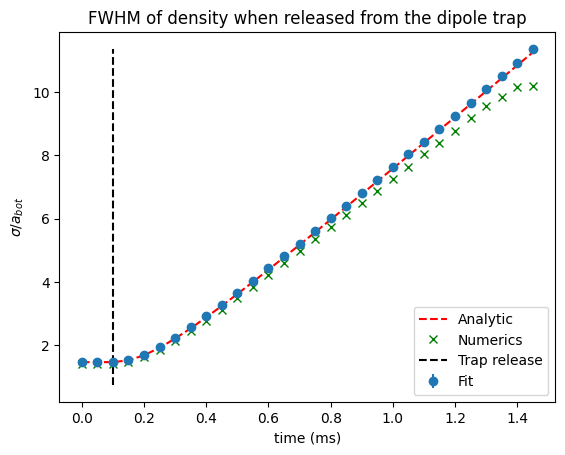

In [72]:
# trap release
t0 = 0.1 # ms

# plot
plt.errorbar(x = time , y = sigma["value"]*np.sqrt(2*np.log(2)) , yerr = sigma["error"] , fmt = "o",label = "Fit")
plt.plot(time , sigmaFormula(time,t0,sigma["value"][0],omegaTrap) , color = "red" , ls = "dashed" , label = "Analytic")
plt.plot(time , width , color = "green" , label = "Numerics" , marker = "x" , ls = "")

plt.vlines(x = t0 , ymin = np.amin(sigma["value"]) - 0.5 , ymax = np.amax(sigma["value"]*np.sqrt(2*np.log(2))) , ls = "dashed" , color = "black" , label = "Trap release")
plt.xlabel("time (ms)")
plt.ylabel(r"$\sigma/a_{bot}$")
plt.legend(loc = "lower right")
plt.title("FWHM of density when released from the dipole trap")
plt.show()

## Lattice TODO

TODO

In [8]:
depth = s_ramp(0, 0, 15, 1e-3)
#cavity = potentials.DispersiveCavity(lattice_depth=depth, cavity_detuning=-15e6, atomic_detuning=-76.6e9, 
#                                     cavity_decay=150e3, cavity_coupling=1.95e6)
lattice = potentials.Lattice(V0 = depth,lam = 1.064e-6)

bec.propagate(2e-3, 1e-6, [lattice, trap, contact])

Propagation: 100%|██████████| 2000/2000 [01:55<00:00]


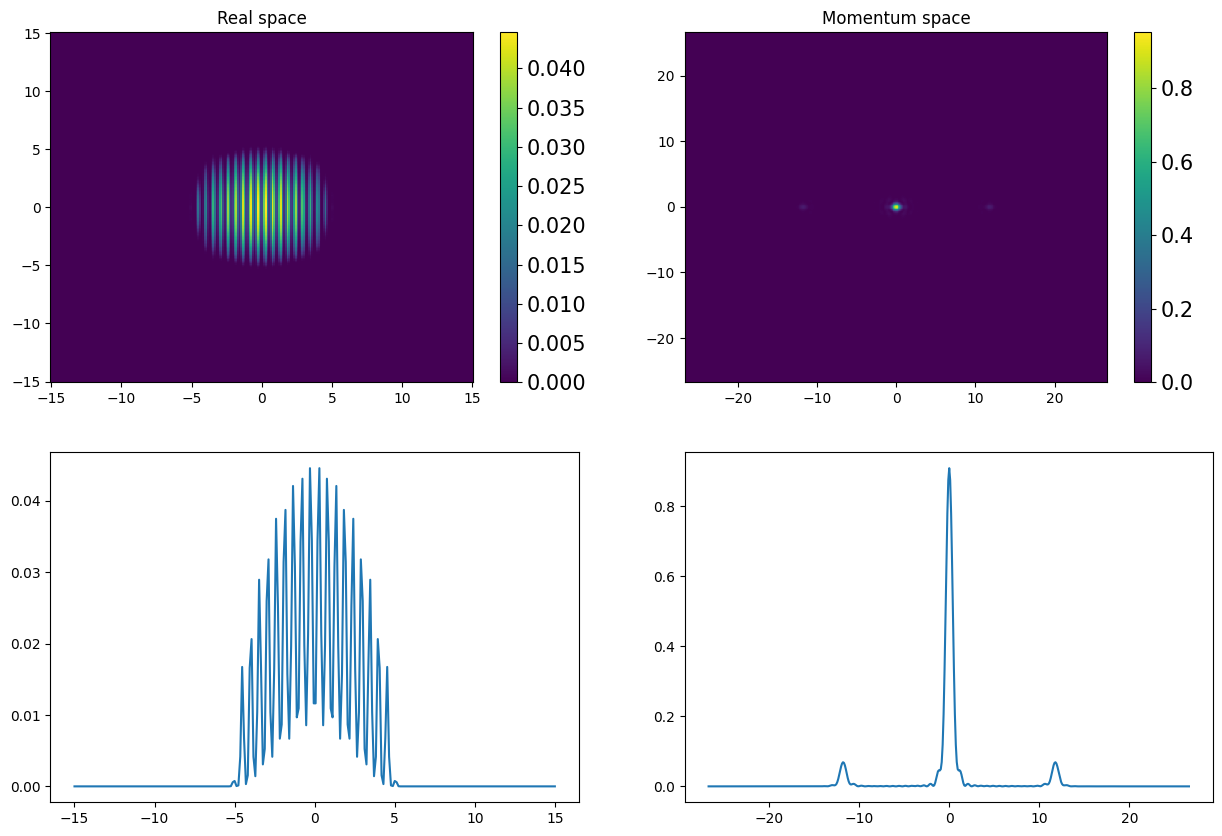

In [9]:
fig, ax = plt.subplots(nrows= 2 , ncols=2,figsize = (15,10))


# plot
im = ax[0,0].pcolormesh(bec.X,bec.Y, bec.density)
cbar = fig.colorbar(im, ax = ax[0,0])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)
ax[0,0].set_title("Real space")

# plot
im = ax[0,1].pcolormesh(bec.Kx,bec.Ky, bec.densityk)
cbar = fig.colorbar(im, ax = ax[0,1])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)
ax[0,1].set_title("Momentum space")


ax[1,0].plot(bec.X[0],bec.density[int(len(bec.density)/2)-1])
ax[1,1].plot(bec.Kx[0],bec.densityk[int(len(bec.densityk)/2)-1])


plt.show()


# BEC in a 3D harmonic trap

In this example, we solve the GP equation for a 3D-harmonic trap. We first find the ground state and after we evolve the BEC order parameter after switch off of the trap.

## Import libraries

In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import torch
import numpy as np
import scipy.constants as spconsts

from heliumtools.simulation.GPE.bec3D import Gas
import heliumtools.simulation.GPE.utils.callbacks as call
import heliumtools.simulation.GPE.bec3D.potentials as potentials

/home/rui/HeliumTools/hellenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Finding Ground state BEC

We start by defining the trap frequency in both x and y-axis. This trap frequency sets the caractering time and length adimensionalization.

In [2]:
# define He mass in SI units
mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

# get hbar in SI units
hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

# define transverse trap frequency in s^-1
omegaR = 2*np.pi*900
# define z-axis trap frequency in s^-1
omegaZ = 2*np.pi*40

# compute characteristic lengths. We use the ground state of the quantum harmonic oscillator as reference
aR = np.sqrt(hbar/(omegaR*mHe))
aZ = np.sqrt(hbar/(omegaZ*mHe))

In [3]:
# We instanciate the Gas class. We define the element we want to consider. This element must be defined in utils/elements.py
# we set the number of atoms in the BEC
# we set the grid_size
grid_size = [8*aR,8*aR,10*aZ]
# we define the number of points of the grid for each axis.
step = [aR/10,aR/10,aZ/10]
Npoints = []
for i in range(0,len(step)):
        Npoints.append(int(grid_size[i]/step[i]))
print("Grid with "+str(Npoints)+" in each axis")
# we set the float type to 32 bit to save memory space
# we set the complex type to 64 bit to save memory space
# calculation is performed on cpu
# define BEC adim length so that it is consistent with the problem


# instanciate Gas class
bec = Gas(element = "He*" , N_particles = 5e4, grid_size = grid_size, N_grid = Npoints ,  
        device = "cpu" , float_dtype = torch.float , complex_dtype = torch.complex64 , adimensionalization_length = np.amin([aR,aZ]))

Grid with [80, 80, 100] in each axis


Now we define the ground state wavefunction of the harmonic oscillator for latter use

In [4]:
# 1D harmonic oscillator
# X should be in adim units
# omega trap frequency
# gas is the instance of the Gas() class
def HarmonicGroundState_1D(X,omega,gas):
    # define He mass in SI units
    mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

    # get hbar in SI units
    hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

    # get adim length
    lAdim = gas.adim_length

    # compute wavefunction length parameter
    length = np.sqrt(hbar/(omega*mHe))

    # compute norm factor
    norm = 1/np.sqrt(np.pi*np.power(length,2))

    # compute wavefunction
    arg = X*lAdim/length
    phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)
    return phi*np.sqrt(lAdim)


# 3D-harmonic ocscillator ground state
# X, Y and Z should be in adim units
# this function is to be used to compare numerical result
# omegaR is the transverse trap frequency
# omegaZ is the z-axis trap frequency
# gas is the instance of the Gas() class
def HarmonicGroundState(X,Y,Z,omegaR,omegaZ,gas):
    
    # compute transverse component
    psiR = HarmonicGroundState_1D(X,omegaR,gas)*HarmonicGroundState_1D(Y,omegaR,gas)

    # compute z-axis component
    psiZ = HarmonicGroundState_1D(Z,omegaZ,gas)

    # compute full wavefunction
    psi = psiR*psiZ

    # compute norm
    # norm = simpson(simpson(simpson(psi**2 , x = gas.x , axis = 0) , x = gas.y , axis = 0) , x = gas.z , axis = 0)

    return psi


# wavefunction according to the gaussian ansatz. Homogenous along z
# X and Y should be in adim units
# this function is to be used to compare numerical result
def GaussianAnsatz(X,Y,n1):
    # define He mass in SI units
    mHe = spconsts.physical_constants["atomic mass constant"][0] * 4

    # get hbar in SI units
    hbar = spconsts.physical_constants["Planck constant over 2 pi"][0]

    # scattering length in SI units
    aScatter = 7.512*1e-9 # m

    # compute radius
    r = X**2 + Y **2

    # compute width
    sigma = np.power(1+4*n1*aScatter,1/4)

    return 1/np.sqrt(np.pi*sigma**2)*np.exp(-r/(2*sigma**2))   

We now define the harmonic trap potential

In [5]:
# instanciate trap potential
trap = potentials.Trap(omegax = omegaR, omegay = omegaR, omegaz = omegaZ)

We now define the nonlinar interaction term of the GP equation as a nonlinear contact potential

In [6]:
""" compute Bohr radius """
Bohr = spconsts.codata.value("Bohr radius")

""" define scattering length for He* in units of Bohr radius """
# scattering length in SI units
aScatter = 7.512*1e-9 # m
# set in Bohr radius units
aScatter = aScatter/Bohr

""" define renormalization parameter for the scattering length to account for the missing third dimension """
# according to the Bragg spetroscopy, we expect that longitudinal density parameter is
n1 = 1.3/(aScatter*Bohr)
# define renormalization parameter
a_orth = bec.adim_length

""" define contact potential """
contact = potentials.Contact(a_s = aScatter , a_orth = a_orth)

/tmp/ipykernel_10549/3585857362.py:2: DeprecationWarning: Please import `value` from the `scipy.constants` namespace; the `scipy.constants.codata` namespace is deprecated and will be removed in SciPy 2.0.0.
  Bohr = spconsts.codata.value("Bohr radius")


Define intial wavefunction

In [ ]:
# we define the initial wavefunction to be the ground state of the harmonic oscillator
bec.psi = HarmonicGroundState(bec.X,bec.Y,bec.Z,omegaR,omegaZ,bec)

/tmp/ipykernel_10549/2064118136.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)


Find ground state of GP equation

In [19]:
# define function that measures convergence of calculation
CP = 500
convergence = call.L2Norm(compute_every = CP, print_every = 1e4)

# find the ground state
Nit = 2e3
bec.ground_state(potentials=[trap], N_iterations=Nit,callbacks=[convergence])

Ground state:   0%|          | 1/2000 [00:03<1:57:17]

tensor(0.0066)


Ground state: 100%|██████████| 2000/2000 [51:24<00:00]


Plot 2D function and cross section

/tmp/ipykernel_10549/2064118136.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.sqrt(norm)*np.exp(-np.power(arg,2)/2)


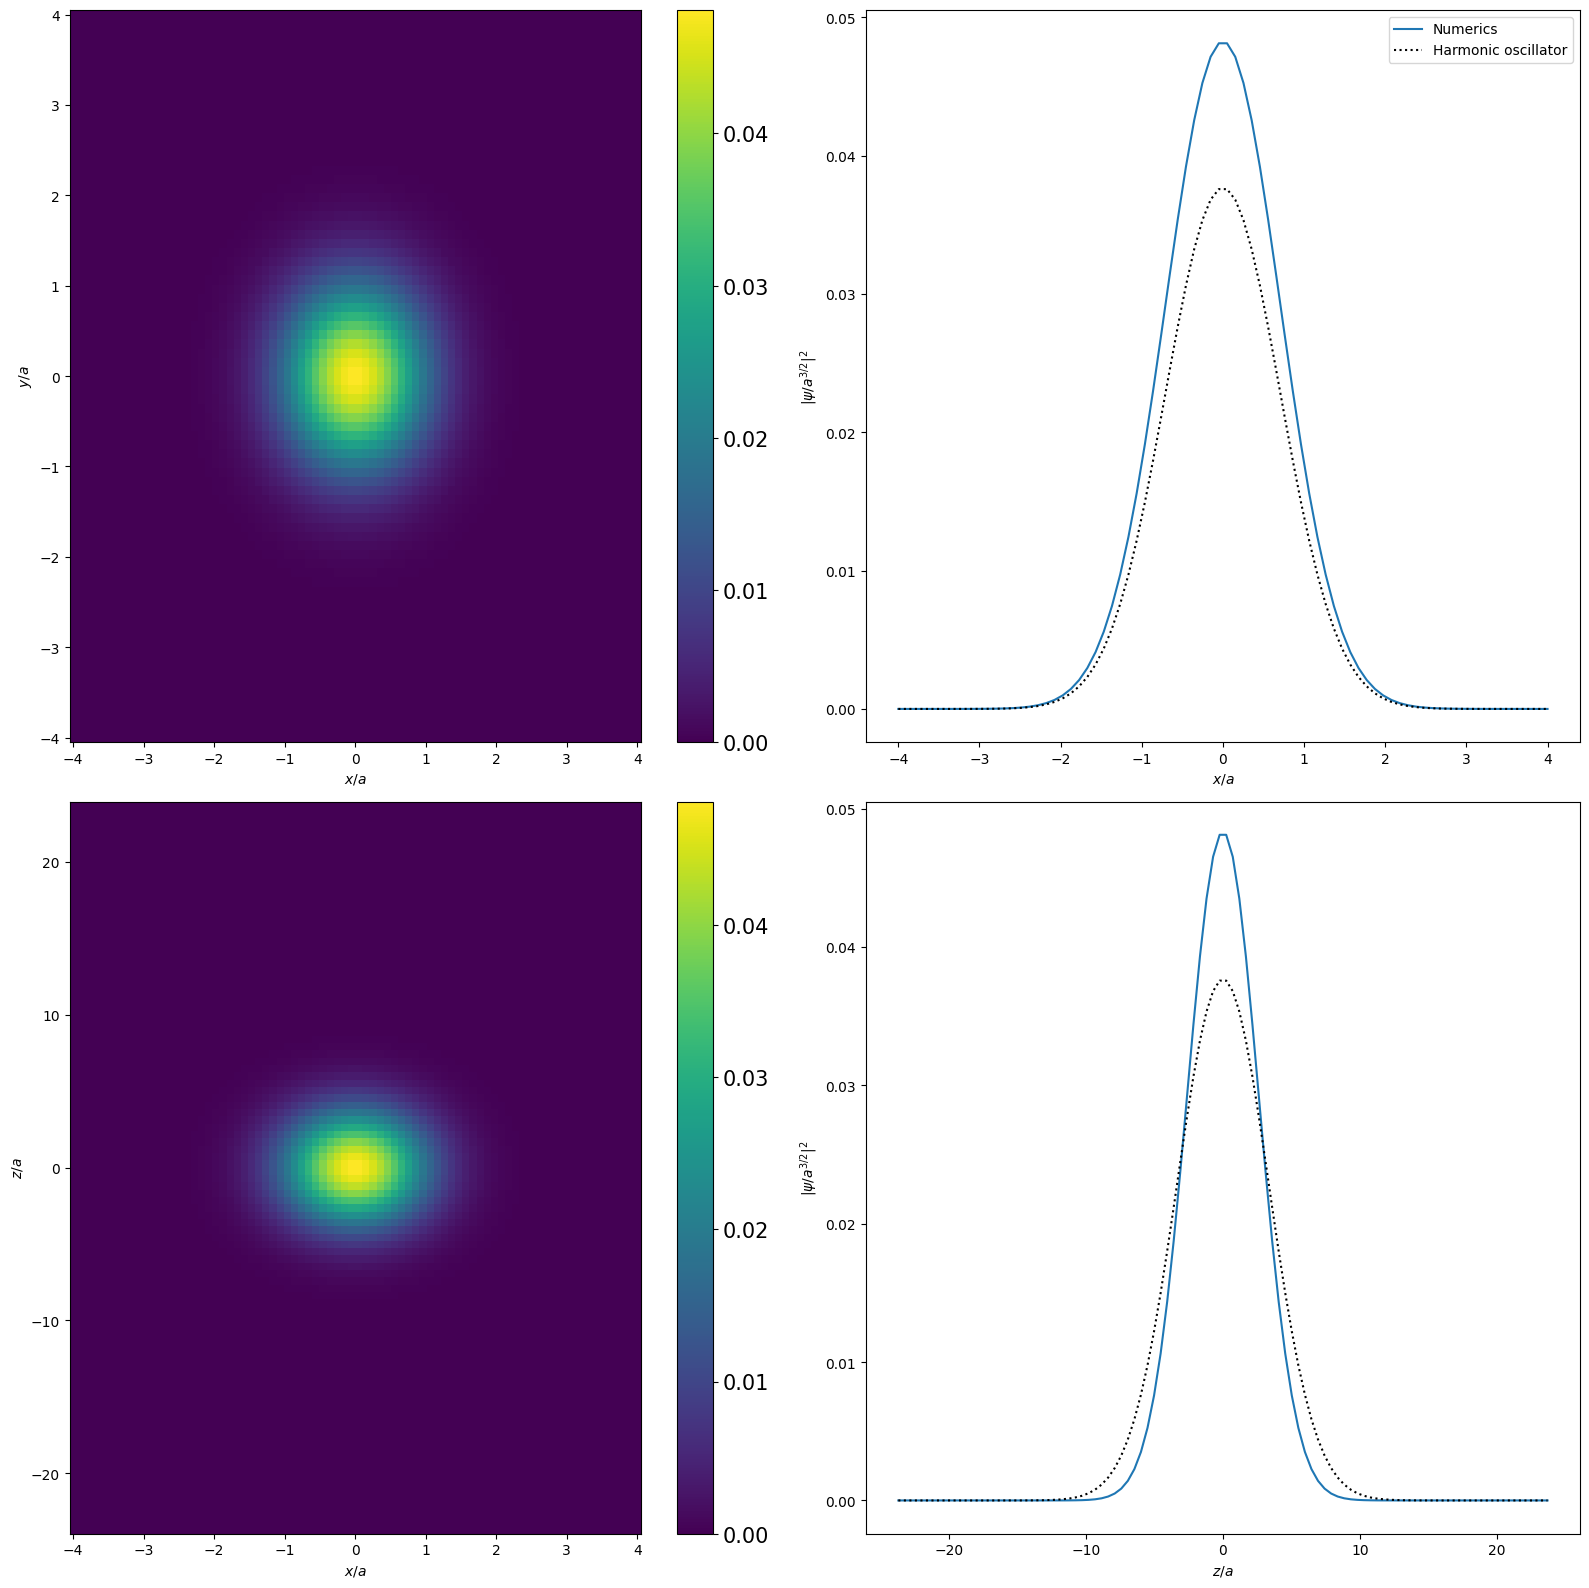

In [20]:
fig, ax = plt.subplots(nrows= 2 , ncols=2,figsize = (16,16))

""" 2D plot """
im = ax[0,0].pcolormesh(bec.X[:,:,50],bec.Y[:,:,50], bec.density[:,:,50])
cbar = fig.colorbar(im, ax = ax[0,0])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)


""" 1D plot along diagonal """
ax[0,1].plot(bec.x,bec.density[:,40,50],label = "Numerics")
# plot original guess which is the quantum harmonic oscillator
phiHarmonic = HarmonicGroundState(bec.X,bec.Y,bec.Z,omegaR,omegaZ,bec)**2
ax[0,1].plot(bec.x,phiHarmonic[:,40,50],label = "Harmonic oscillator",color = "black" , ls = "dotted")


""" 2D plot """
Z , X = np.meshgrid(bec.z,bec.x)
im = ax[1,0].pcolormesh(X,Z,bec.density[:,40,:])
cbar = fig.colorbar(im, ax = ax[1,0])
for s in cbar.ax.get_yticklabels():
    s.set_fontsize(15)


""" 1D plot along diagonal """
ax[1,1].plot(bec.z,bec.density[40,40,:])
# plot original guess which is the quantum harmonic oscillator
ax[1,1].plot(bec.z,phiHarmonic[40,40,:],color = "black" , ls = "dotted")

ax[0,0].set_xlabel(r"$x/a$")
ax[0,0].set_ylabel(r"$y/a$")
ax[0,1].set_xlabel(r"$x/a$")
ax[0,1].set_ylabel(r"$|\psi/a^{3/2}|^2$")
ax[0,1].legend()

ax[1,0].set_xlabel(r"$x/a$")
ax[1,0].set_ylabel(r"$z/a$")
ax[1,1].set_xlabel(r"$z/a$")
ax[1,1].set_ylabel(r"$|\psi/a^{3/2}|^2$")

plt.tight_layout()
plt.show()

Plot convergence of calculation

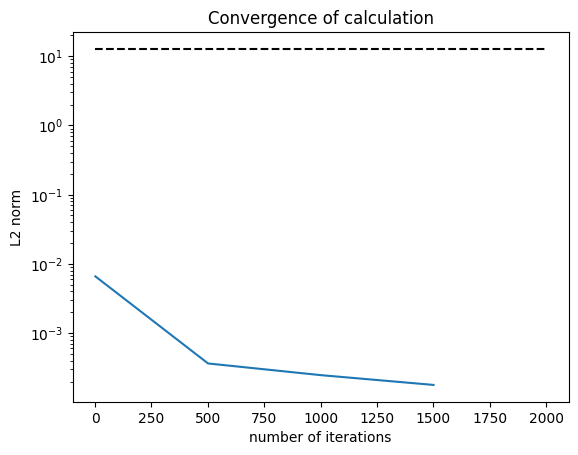

In [21]:
plt.plot(np.arange(1,Nit+1,CP),convergence.norms)

soma = torch.sqrt(torch.sum(torch.abs(phiHarmonic-bec.psi)**2)).cpu()
plt.hlines(y = soma, xmin = 0 , xmax = 2e3 , ls = "dashed" , color = "black")

plt.xlabel("number of iterations")
plt.ylabel("L2 norm")
plt.yscale("log")
plt.title("Convergence of calculation")
plt.show()